In [16]:
import pandas as pd
df = pd.read_csv("./Data/lendingclub_full_encoded.csv")
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,annual_inc,addr_state,dti,...,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_major_purchase,purpose_medical,purpose_other,purpose_small_business,verification_status_Source Verified,verification_status_Verified
0,3600.0,3600.0,3600.0,36,13.99,123.03,10.0,55000.0,PA,5.91,...,False,False,True,False,False,False,False,False,False,False
1,24700.0,24700.0,24700.0,36,11.99,820.28,10.0,65000.0,SD,16.06,...,False,False,False,False,False,False,False,True,False,False
2,20000.0,20000.0,20000.0,60,10.78,432.66,10.0,63000.0,IL,10.78,...,False,False,False,True,False,False,False,False,False,False
3,10400.0,10400.0,10400.0,60,22.45,289.91,3.0,104433.0,PA,25.37,...,False,False,False,False,True,False,False,False,True,False
4,11950.0,11950.0,11950.0,36,13.44,405.18,4.0,34000.0,GA,10.20,...,True,False,True,False,False,False,False,False,True,False


In [17]:
# Check data state
print(df.shape)
print(df.columns)
print(df['loan_default'].value_counts(normalize=True))


(611780, 105)
Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'emp_length', 'annual_inc', 'addr_state', 'dti',
       ...
       'home_ownership_RENT', 'purpose_credit_card',
       'purpose_debt_consolidation', 'purpose_home_improvement',
       'purpose_major_purchase', 'purpose_medical', 'purpose_other',
       'purpose_small_business', 'verification_status_Source Verified',
       'verification_status_Verified'],
      dtype='str', length=105)
loan_default
0    0.788836
1    0.211164
Name: proportion, dtype: float64


# Step 1: Baseline Model — Decision Tree

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# STEP 1: Reload from main dataframe 
# Make a copy to avoid modifying original
df_model = df.copy()

# STEP 2: Define ALL columns that leak information
leakage_cols = [
    'loan_status', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'last_pymnt_d', 'last_pymnt_amnt', 'recoveries', 'collection_recovery_fee',
    'out_prncp', 'out_prncp_inv', 'next_pymnt_d','last_fico_range_high',
    'last_fico_range_low'
]

# STEP 3: Split features & target
X = df_model.drop(columns=[*leakage_cols, 'loan_default'], errors='ignore')
y = df_model['loan_default']

# STEP 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# STEP 5: Keep only numeric features
X_train = X_train.select_dtypes(include='number')
X_test = X_test[X_train.columns]

# STEP 6: Fill missing values
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# STEP 7: Train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=6,                 # tránh overfitting
    min_samples_split=50,        # tăng độ ổn định
    class_weight='balanced',     # xử lý imbalance
    random_state=42
)

dt_model.fit(X_train, y_train)

# STEP 8: Predict
y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

# STEP 9: Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_proba), 4))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_proba), 4))


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.63      0.73     96519
           1       0.33      0.68      0.45     25837

    accuracy                           0.64    122356
   macro avg       0.61      0.66      0.59    122356
weighted avg       0.77      0.64      0.67    122356


Confusion Matrix:
 [[60613 35906]
 [ 8139 17698]]

ROC-AUC Score: 0.7165
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.63      0.73     96519
           1       0.33      0.68      0.45     25837

    accuracy                           0.64    122356
   macro avg       0.61      0.66      0.59    122356
weighted avg       0.77      0.64      0.67    122356


Confusion Matrix:
 [[60613 35906]
 [ 8139 17698]]

ROC-AUC Score: 0.7165


# Step 2:  Build a Tree-Based Model (XGBoost)


#### Calculate scale_pos_weight

In [19]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 3.7356433056923626


#### Build XGBoost Model

In [20]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)


c:\Users\anhkh\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:51:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_proba_xgb), 4))


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.68      0.77     96519
           1       0.36      0.67      0.47     25837

    accuracy                           0.68    122356
   macro avg       0.62      0.67      0.62    122356
weighted avg       0.77      0.68      0.70    122356


Confusion Matrix:
 [[65297 31222]
 [ 8531 17306]]

ROC-AUC Score: 0.7384


# Step 3: ROC Curves (XGBoost vs Decision Tree)

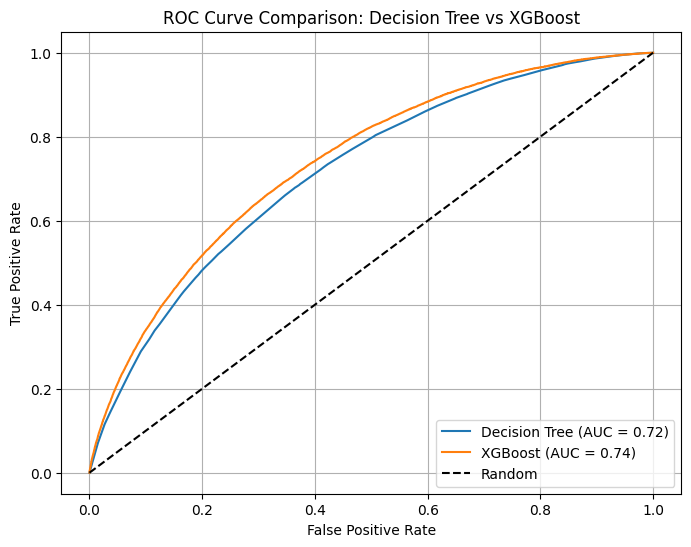

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot both ROC Curves
plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

# Baseline
plt.plot([0,1], [0,1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Decision Tree vs XGBoost')
plt.legend(loc='lower right')
plt.grid()
plt.show()


# Step 4: Extract and plot Feature Importance from XGBoost.

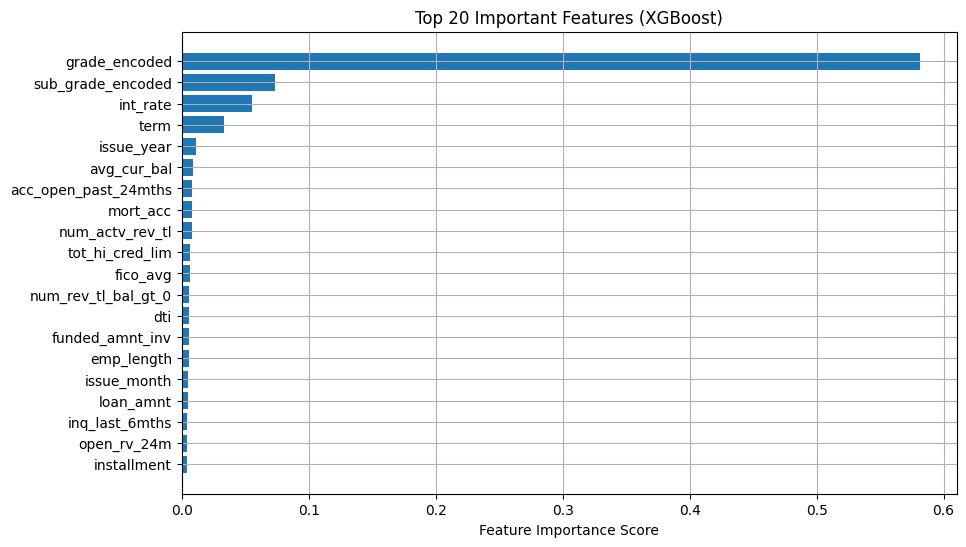


Top 10 Important Features:
                 Feature  Importance
76         grade_encoded    0.581293
77     sub_grade_encoded    0.073100
4               int_rate    0.055302
3                   term    0.033004
72            issue_year    0.011102
37           avg_cur_bal    0.008935
36  acc_open_past_24mths    0.008263
46              mort_acc    0.008214
52       num_actv_rev_tl    0.008183
68       tot_hi_cred_lim    0.006593


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Get feature importances from XGBoost model
feature_importances = xgb_model.feature_importances_

# Step 2: Map to column names
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Step 3: Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Step 4: Plot Top 20 Features
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:20][::-1], importance_df['Importance'][:20][::-1])
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Important Features (XGBoost)')
plt.grid()
plt.show()

# Step 5: (Optional) Show Top 10 Features Textually
print("\nTop 10 Important Features:")
print(importance_df.head(10))


# Step 5: SHAP (SHapley Additive exPlanations)


It explains individual loan predictions (why one loan defaulted, another didn't).
It shows positive/negative pushes on risk.
It's becoming industry standard in credit scoring explainability.

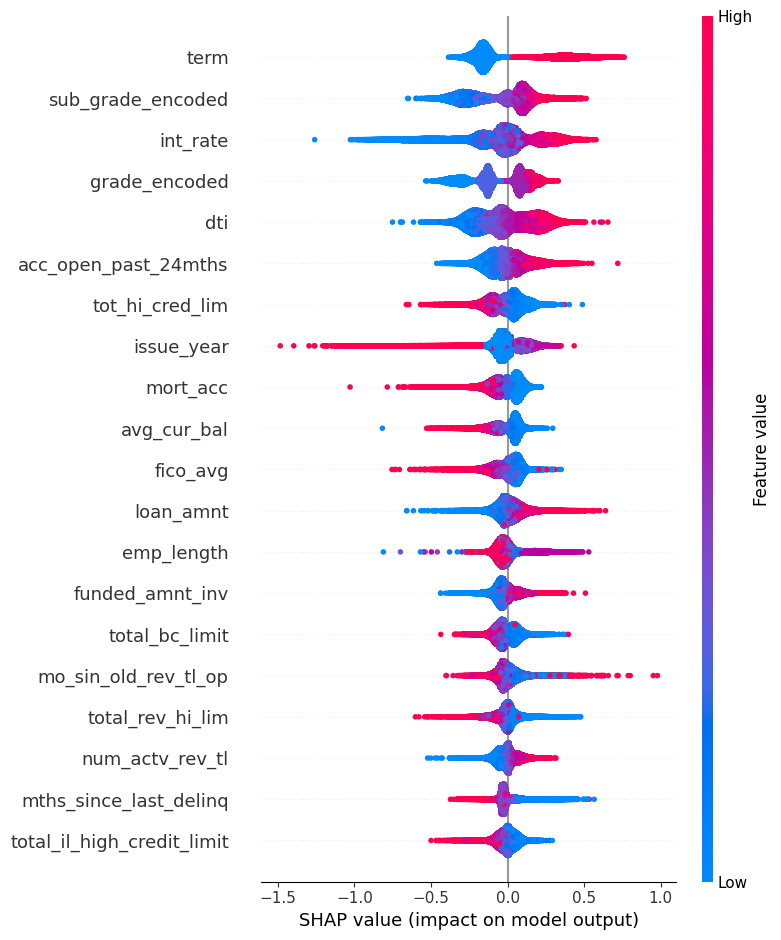

In [24]:
import shap

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Get SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Big summary plot
shap.summary_plot(shap_values, X_test)


# Fine-Tuning, Threshold Tuning, and Finalizing Models

##### Step 1: RandomizedSearchCV for XGBoost

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Define basic model
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Define hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5, 7]
}

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,  # Search 20 combinations randomly
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit search
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters found: ", random_search.best_params_)

# Best model
best_xgb_model = random_search.best_estimator_


Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\anhkh\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:58:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters found:  {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}


#### Retrain XGBoost with Best Parameters 

In [26]:
# Train best XGBoost model
from xgboost import XGBClassifier

final_xgb_model = XGBClassifier(
    subsample=0.9,
    n_estimators=300,
    min_child_weight=5,
    max_depth=7,
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Fit on full training set
final_xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_final = final_xgb_model.predict(X_test)
y_proba_final = final_xgb_model.predict_proba(X_test)[:,1]

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:\n", classification_report(y_test, y_pred_final))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, y_proba_final), 4))


c:\Users\anhkh\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:58:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.68      0.77     96519
           1       0.36      0.67      0.47     25837

    accuracy                           0.68    122356
   macro avg       0.62      0.68      0.62    122356
weighted avg       0.77      0.68      0.70    122356


Confusion Matrix:
 [[65341 31178]
 [ 8439 17398]]

ROC-AUC Score: 0.7421


## Threshold Tuning 

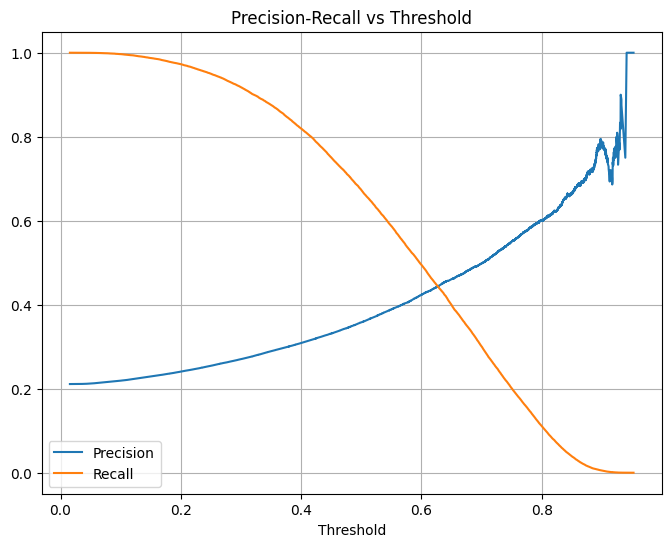

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Calculate precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_final)

# Plot
plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid()
plt.show()


### Apply New Threshold 

In [28]:
# New Predictions based on threshold 0.45
y_pred_threshold = (y_proba_final >= 0.45).astype(int)

# Evaluate new predictions
print("Classification Report:\n", classification_report(y_test, y_pred_threshold))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_threshold))


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.59      0.72     96519
           1       0.33      0.75      0.46     25837

    accuracy                           0.63    122356
   macro avg       0.62      0.67      0.59    122356
weighted avg       0.78      0.63      0.66    122356


Confusion Matrix:
 [[57425 39094]
 [ 6439 19398]]


# SAVING MODEL

In [29]:
import pickle

# Save Logistic Regression model
with open('Decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

# Save Fine-tuned XGBoost model
with open('xgboost_final_model.pkl', 'wb') as f:
    pickle.dump(final_xgb_model, f)


# Train the dummy dashboard model 

In [33]:
# Select only important columns
# important_features = ['fico_avg', 'log_income', 'loan_amnt', 'term', 'dti']
important_features = [
    "int_rate",
    "loan_amnt",
    "annual_inc",
    "term",
    "dti",
    "fico_avg"   
]

# Re-train XGBoost on these
from xgboost import XGBClassifier

dashboard_model = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

dashboard_model.fit(X_train[important_features], y_train)

# Save it
import pickle

with open('xgboost_dashboard_model.pkl', 'wb') as f:
    pickle.dump(dashboard_model, f)


c:\Users\anhkh\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:18:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
